# Imports

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import torch.utils.data as data
from torch.utils.data import random_split

from PIL import Image

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import numpy as np

from tqdm.notebook import tqdm

import os
import random

### Set device and seed

In [2]:
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # set device
print(device)

cuda


# Load Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.EuroSAT(root='./data', transform=transform, download=True)

100%|██████████| 94.3M/94.3M [00:02<00:00, 40.6MB/s]


## EDA

In [4]:
# Distribution of classes

class_to_idx = dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_counts = {}
for _, label in tqdm(dataset):
    label = idx_to_class[label]

    if label in class_counts:
        class_counts[label] += 1
    else:
        class_counts[label] = 1



print("Class distribution:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

  0%|          | 0/27000 [00:00<?, ?it/s]

Class distribution:
AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


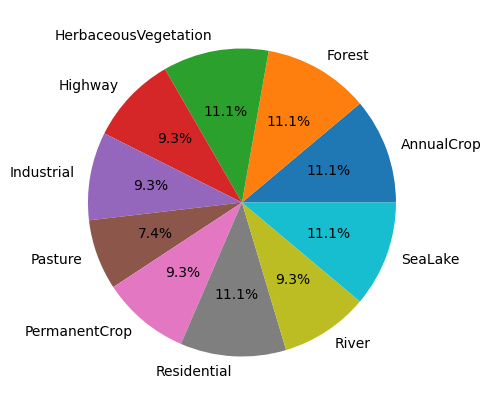

In [5]:
labels = class_counts.keys()
counts = class_counts.values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.pie(counts, labels=labels, autopct="%1.1f%%")
plt.show()

## Splitting

In [6]:
# 70-15-15 split of dataset into train, val and test sets using torch random split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])


## Data Augmentation

In [7]:
class customDataset(data.Dataset):
    """
    Custom dataset class to apply augmentations to the dataset.
    """
    def __init__(self, dataset, transform: transforms.Compose):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx) :
        x, y = self.dataset[idx]

        # Apply transformations to the image
        if self.transform:
            x = self.transform(x)
        
        return x, y

In [8]:
# Augmentations to apply: flipping, rotation, random crop and resize
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
])

train_dataset_aug = customDataset(train_dataset, transform=transform_aug)
val_dataset_aug = customDataset(val_dataset, transform=transform_aug)
test_dataset_enc = customDataset(test_dataset, transform=None)

# Sizes of the splits
print(f"Train dataset size: {len(train_dataset_aug)}")
print(f"Validation dataset size: {len(val_dataset_aug)}")
print(f"Test dataset size: {len(test_dataset_enc)}")

train_loader = data.DataLoader(train_dataset_aug, batch_size=128, shuffle=True)
val_loader = data.DataLoader(val_dataset_aug, batch_size=128, shuffle=False)
test_loader = data.DataLoader(test_dataset_enc, batch_size=1, shuffle=False)

Train dataset size: 18900
Validation dataset size: 4050
Test dataset size: 4050


# Training

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # A shortcut connection to match the dimensions of the input and output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out
    
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 128, stride=2)
        self.layer2 = self._make_layer(128, 256, stride=2)
        self.layer3 = self._make_layer(256, 512, stride=2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.conv2 = nn.Conv2d(512, num_classes, kernel_size=1)

    def _make_layer(self, in_channels, out_channels, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.gap(out)
        out = self.conv2(out)
        out = torch.flatten(out, 1) # flatten the output
        return out

In [10]:
model = ResNet(num_classes=10).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(1

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 Train:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/25 Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/25 Train:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 2/25 Val:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 23/25 Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 24/25 Train:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/25 Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 25/25 Train:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/25 Val:   0%|          | 0/32 [00:00<?, ?it/s]

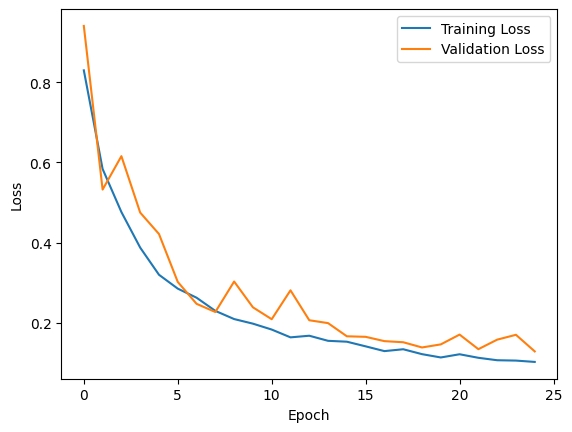

In [12]:
num_epochs = 25
train_losses = []
val_losses = []
model=model.to(device)

pbar = tqdm(range(num_epochs), desc="Training")
for epoch in pbar:
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Val", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    pbar.set_postfix(train_loss=f"{train_losses[-1]:.4f}", val_loss=f"{val_losses[-1]:.4f}")

# Plot the training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluation

In [18]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    confusion_mat = confusion_matrix(all_labels, all_preds)

    return accuracy, f1, confusion_mat, all_preds, all_labels

# Evaluate the model
test_accuracy, test_f1, confusion_mat, all_preds, all_labels = evaluate_model(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Confusion Matrix:\n{confusion_mat}")

Evaluating:   0%|          | 0/4050 [00:00<?, ?it/s]

Test Accuracy: 0.9659
Test F1 Score: 0.9659
Confusion Matrix:
[[442   1   3   2   0   7  13   0   0   4]
 [  0 439   0   0   0   2   0   0   1   0]
 [  1   2 440   1   2   5   6   1   0   0]
 [  1   0   1 384   2   0   2   1   0   0]
 [  0   0   0   0 370   0   0   8   0   0]
 [  2   2   4   0   0 289   0   0   1   1]
 [  4   1  13   1   2   2 353   2   1   0]
 [  0   0   0   0   5   0   0 445   0   0]
 [  8   1   2   7   2   2   0   0 352   1]
 [  2   1   3   0   0   0   0   0   2 398]]


# Deepfool MultiClass

In [19]:
def deepfool_attack(image, model, num_classes=10, overshoot=0.02, max_iter=50, device="cuda"):
    """
    DeepFool adversarial attack for a single image (multiclass case).

    Args:
        image: input tensor [C,H,W]
        model: trained classifier
        num_classes: number of classes
        overshoot: small factor to pass the boundary
        max_iter: maximum DeepFool iterations

    Returns:
        perturbed_image
        total_perturbation
        num_iterations
    """

    model.eval()

    # Input image x
    image = image.clone().detach().to(device)

    # Initialize x0 <- x, i <- 0
    x_i = image.clone().detach()
    x_i.requires_grad = True
    i = 0

    # Compute initial prediction k_hat(x_0)
    with torch.no_grad():
        logits = model(image.unsqueeze(0))
        _, label = torch.max(logits, 1)
    label = label.item()

    # Total perturbation r_hat
    r_tot = torch.zeros_like(image)

    # Current predicted label
    logits = model(x_i.unsqueeze(0))
    _, current = torch.max(logits, 1)
    current = current.item()

    # While k_hat(x_i) = k_hat(x_0)
    while current == label and i < max_iter:

        x = x_i.unsqueeze(0)

        # Compute classifier outputs f_k(x_i)
        logits = model(x)
        f = logits[0]

        # Compute gradient of the original class ∇f_{k_hat(x_0)}(x_i)
        grad_orig = torch.autograd.grad(f[label], x, retain_graph=True)[0]

        min_pert = float("inf")
        w_best = None

        # For k != k_hat(x_0)
        for k in range(num_classes):

            if k == label:
                continue

            # w_k' ← ∇f_k(x_i) − ∇f_{k_hat(x_0)}(x_i)
            grad_k = torch.autograd.grad(f[k], x, retain_graph=True)[0]
            w_k = grad_k - grad_orig

            # f_k ← f_k(x_i) − f_{k_hat(x_0)}(x_i)
            f_k = f[k] - f[label]

            # Compute distance to decision boundary
            w_k_norm = torch.norm(w_k.flatten(), p=2)
            pert_k = torch.abs(f_k) / w_k_norm

            # Find class giving minimal perturbation
            if pert_k < min_pert:
                min_pert = pert_k
                w_best = w_k

        # r_i ← |f_l'| / ||w_l'||^2 * w_l'
        r_i = (min_pert + 1e-4) * w_best / torch.norm(w_best.flatten(), p=2)

        # Accumulate perturbation
        r_tot = r_tot + r_i.squeeze(0)

        # x_{i+1} ← x_i + r_i
        x_i = image + (1 + overshoot) * r_tot
        x_i = x_i.detach()
        x_i.requires_grad = True

        # i ← i + 1
        i += 1

        # Update predicted label
        logits = model(x_i.unsqueeze(0))
        _, current = torch.max(logits, 1)
        current = current.item()

    # Final adversarial example
    perturbed_image = (image + (1 + overshoot) * r_tot).detach()

    # Return r_hat = Sum_i (r_i)
    return perturbed_image, r_tot.detach(), i

In [20]:
def generate_adversarial_dataset(model, dataloader, device="cuda"):
    """
    Generates adversarial dataset using DeepFool.

    Returns:
        adv_images (tensor)
        adv_labels (tensor)
    """

    model.eval()

    adv_images = []
    adv_labels = []

    for images, labels in tqdm(dataloader, desc="Generating adversarial examples"):

        images = images.to(device)
        labels = labels.to(device)

        for i in range(images.size(0)):

            img = images[i]

            adv_img, _, _ = deepfool_attack(img, model, device=device)

            adv_images.append(adv_img.cpu())
            adv_labels.append(labels[i].cpu())

    adv_images = torch.stack(adv_images)
    adv_labels = torch.stack(adv_labels)

    return adv_images, adv_labels

In [21]:
def evaluate_model_adversarial(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(test_loader, desc="Evaluating (Adversarial)"):
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.item())
        all_labels.append(labels.item())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    confusion_mat = confusion_matrix(all_labels, all_preds)

    return accuracy, f1, confusion_mat, all_preds, all_labels


# Evaluate model on adversarial data
adv_images, adv_labels = generate_adversarial_dataset(model, test_loader, device)
adv_dataset = data.TensorDataset(adv_images, adv_labels)
adv_loader = data.DataLoader(adv_dataset, batch_size=1, shuffle=False)

adv_accuracy, adv_f1, adv_confusion, adv_preds, adv_labels = evaluate_model_adversarial(model, adv_loader)

print(f"Adversarial Accuracy: {adv_accuracy:.4f}")
print(f"Adversarial F1 Score: {adv_f1:.4f}")
print(f"Adversarial Confusion Matrix:\n{adv_confusion}")

Generating adversarial examples:   0%|          | 0/4050 [00:00<?, ?it/s]

Evaluating (Adversarial):   0%|          | 0/4050 [00:00<?, ?it/s]

Adversarial Accuracy: 0.0267
Adversarial F1 Score: 0.0271
Adversarial Confusion Matrix:
[[ 24  14  40 172   0  33 116   0  55  18]
 [110   2  92   0   0  70   1   4  70  93]
 [ 19  45  13  43  25  57 141  86  24   5]
 [ 34   2  19   5  61  31  61  34 143   1]
 [  0   0 141 119   7   0  14  86  11   0]
 [ 31 151  35   9   0   9  27   0  31   6]
 [ 62   3 176  73   8  10  17  16  14   0]
 [  0   2 135  22 243   2  36   5   5   0]
 [103  31  55  83  15  25  19  10  18  16]
 [ 47 212 113   3   0  14   0   0   9   8]]


### Success rate

In [22]:
def deepfool_attack_success_rate(all_labels, clean_preds, adv_preds):
    all_labels = np.array(all_labels)
    clean_preds = np.array(clean_preds)
    adv_preds = np.array(adv_preds)

    # Samples correctly classified by the clean model
    initially_correct = clean_preds == all_labels

    # Among those, check which became incorrect after attack
    successful_attacks = adv_preds != all_labels

    # Intersection of the two conditions
    success_mask = initially_correct & successful_attacks

    if initially_correct.sum() == 0:
        return 0.0

    success_rate = success_mask.sum() / initially_correct.sum()

    return success_rate


success_rate = deepfool_attack_success_rate(all_labels, all_preds, adv_preds)

print(f"DeepFool Attack Success Rate: {success_rate:.4f}")

DeepFool Attack Success Rate: 1.0000


## Using torchattack

In [28]:
import torchattack

attack = torchattack.DeepFool(model, num_classes=10, steps=50, overshoot=0.02)

adv_images = []
adv_labels = []

model.eval()

for inputs, labels in tqdm(test_loader, desc="Generating adversarial examples with TorchAttack"):
    inputs, labels = inputs.to(device), labels.to(device)

    adv = attack(inputs, labels)

    adv_images.append(adv.detach().cpu())
    adv_labels.append(labels.detach().cpu())

adv_images = torch.cat(adv_images)
adv_labels = torch.cat(adv_labels)

adv_dataset = data.TensorDataset(adv_images, adv_labels)
adv_loader = data.DataLoader(adv_dataset, batch_size=1, shuffle=False)

# Evaluate on adversarial samples
adv_accuracy_torch, adv_f1_torch, adv_confusion_torch, adv_preds_torch, adv_labels_torch = evaluate_model_adversarial(model, adv_loader)

print(f"Adversarial Accuracy (torchattacks): {adv_accuracy_torch:.4f}")
print(f"Adversarial F1 Score (torchattacks): {adv_f1_torch:.4f}")
print(f"Adversarial Confusion Matrix:\n{adv_confusion_torch}")

Generating adversarial examples with TorchAttack:   0%|          | 0/4050 [00:00<?, ?it/s]

Evaluating (Adversarial):   0%|          | 0/4050 [00:00<?, ?it/s]

Adversarial Accuracy (torchattacks): 0.0748
Adversarial F1 Score (torchattacks): 0.0306
Adversarial Confusion Matrix:
[[  3   1  66 102   0   7 174   0  41  78]
 [  0   0   0   0   0   2   0   0   1 439]
 [ 41   2   0  84   7   5  82  23   2 212]
 [ 65   0  66   0  37   0  66  21  12 124]
 [  0   0   5 224   0   0  65  73  10   1]
 [ 41   2  10  15   0   0   0   0   1 230]
 [111   1 161  46   4   4   0   7  11  34]
 [  1   0 120 127  75   0 110   0   6  11]
 [ 38   1  27  94   2   2  23   0   0 188]
 [ 34   1  64   4   0   0   0   1   2 300]]


## Compare success rate

In [29]:
def compute_attack_success_rate(labels, clean_preds, adv_preds):
    labels = np.array(labels)
    clean_preds = np.array(clean_preds)
    adv_preds = np.array(adv_preds)

    initially_correct = clean_preds == labels
    successful_attacks = adv_preds != labels

    success_mask = initially_correct & successful_attacks

    if initially_correct.sum() == 0:
        return 0.0

    return success_mask.sum() / initially_correct.sum()


# Success rates
custom_success = compute_attack_success_rate(all_labels, all_preds, adv_preds)
torch_success = compute_attack_success_rate(all_labels, all_preds, adv_preds_torch)

print("DeepFool Attack Success Rate Comparison")
print("---------------------------------------")
print(f"Custom DeepFool Implementation : {custom_success:.4f}")
print(f"TorchAttacks DeepFool          : {torch_success:.4f}")

DeepFool Attack Success Rate Comparison
---------------------------------------
Custom DeepFool Implementation : 1.0000
TorchAttacks DeepFool          : 0.9225
